# 04 - Evaluate Models and Robustness

This notebook evaluates the trained policies after the environment-specific
training notebooks have completed.

What this notebook does:

- loads the completed default and tuned models
- runs clean deterministic evaluation with the same episode count for all models
- computes return, episode length, fall rate, and truncation rate
- runs action-noise robustness tests
- inspects Walker2d fall rate across training budgets
- displays the deterministic-vs-stochastic evaluation table

The outputs from this notebook feed directly into the statistics and report
notebooks.

## Load project

In [1]:
from pathlib import Path
import os, sys, time, json

def find_project_root():
    for candidate in [Path.cwd(), Path.cwd().parent, Path(r"D:/MuJoCo_RL_Project")]:
        if (candidate / "project_utils.py").exists():
            return candidate.resolve()
    raise RuntimeError("project_utils.py was not found")

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

import project_utils as pu
pu.set_plot_style()
pu.ensure_dirs()

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.executable}")


[project_utils] Loaded - Project root: D:\MuJoCo_RL_Project
  Python 3.10.20 | SB3 2.9.0 | Gymnasium 1.3.0
  Torch 2.12.1+cu126 | CUDA: True | GPU: NVIDIA RTX 5000 Ada Generation
Project root: D:\MuJoCo_RL_Project
Python: C:\Users\digilians01\.conda\envs\RL_PROJECT\python.exe


## Evaluation targets

The evaluation notebook uses completed default and tuned models. Each model is
evaluated under the same protocol so the final comparison is fair across
algorithms and environments.

In [2]:
EVAL_TRACKS = ["default_1m", "tuned_1m"]
registry = pu.load_registry()
targets = registry[
    registry["track"].isin(EVAL_TRACKS)
    & (registry["status"] == "complete")
    & registry["model_path"].notna()
].copy()
targets = targets[targets["model_path"].map(lambda p: Path(str(p)).exists())]
print(f"Targets: {len(targets)}")
display(targets.groupby(["track", "env_id", "algorithm"]).size().reset_index(name="runs"))


Targets: 96


,track,env_id,algorithm,runs
0,default_1m,HalfCheetah-v5,DDPG,3
1,default_1m,HalfCheetah-v5,PPO,3
2,default_1m,HalfCheetah-v5,SAC,5
3,default_1m,HalfCheetah-v5,TD3,3
4,default_1m,HalfCheetah-v5,TQC,3
5,default_1m,Hopper-v5,DDPG,3
6,default_1m,Hopper-v5,PPO,3
7,default_1m,Hopper-v5,SAC,5
8,default_1m,Hopper-v5,TD3,3
9,default_1m,Hopper-v5,TQC,3


## Standard deterministic evaluation

This step evaluates each completed model without action noise. The policy uses
deterministic actions so the result measures the learned policy itself rather
than extra sampling randomness at test time.

In [3]:
FINAL_EVAL_PATH = pu.RESULTS_PROCESSED / "final_eval_all.csv"
N_EVAL_EPISODES = 20
final_eval = pd.read_csv(FINAL_EVAL_PATH) if FINAL_EVAL_PATH.exists() else pd.DataFrame()

expected = set(targets["run_id"])
done = set(final_eval["run_id"]) if not final_eval.empty else set()
missing = sorted(expected - done)
print(f"Existing evaluation rows: {len(final_eval)}")
print(f"Missing run_ids: {len(missing)}")


Existing evaluation rows: 96
Missing run_ids: 0


In [4]:
if missing:
    records = []
    for _, run in targets[targets["run_id"].isin(missing)].iterrows():
        model_path = str(run["model_path"])
        vec_path = model_path.replace(".zip", "__vecnormalize.pkl")
        vec_path = vec_path if Path(vec_path).exists() else None
        result = pu.evaluate_model_standard(
            model_path=model_path, env_id=run["env_id"], algorithm=run["algorithm"],
            n_eval_episodes=N_EVAL_EPISODES, deterministic=True,
            vecnormalize_path=vec_path, seed=1000 + int(run["seed"]), device="auto",
        )
        result.update(run[["run_id", "track", "env_id", "algorithm",
                           "setting_name", "seed", "total_timesteps"]].to_dict())
        result["checkpoint_type"] = "final"
        records.append(result)
    final_eval = pd.concat([final_eval, pd.DataFrame(records)], ignore_index=True)
    pu.RESULTS_PROCESSED.mkdir(parents=True, exist_ok=True)
    final_eval.to_csv(FINAL_EVAL_PATH, index=False)
else:
    print("Standard evaluation table is complete.")


Standard evaluation table is complete.


## Evaluation summary

This table aggregates the clean evaluation results by track, environment, and
algorithm. It gives a quick view of final return, fall rate, and survival length
before we move to stress testing.

In [5]:
eval_summary = (final_eval.groupby(["track", "env_id", "algorithm"])
                .agg(runs=("run_id", "nunique"),
                     mean_return=("mean_return", "mean"),
                     mean_fall_rate=("fall_rate", "mean"),
                     mean_ep_length=("mean_ep_length", "mean"))
                .reset_index())
display(eval_summary.round(3))


,track,env_id,algorithm,runs,mean_return,mean_fall_rate,mean_ep_length
0,default_1m,HalfCheetah-v5,DDPG,3,7424.107,0.000,1000.000
1,default_1m,HalfCheetah-v5,PPO,3,1620.147,0.000,1000.000
2,default_1m,HalfCheetah-v5,SAC,5,8852.285,0.000,1000.000
3,default_1m,HalfCheetah-v5,TD3,3,10479.534,0.000,1000.000
4,default_1m,HalfCheetah-v5,TQC,3,10399.716,0.000,1000.000
5,default_1m,Hopper-v5,DDPG,3,2212.721,0.550,644.583
6,default_1m,Hopper-v5,PPO,3,1670.549,0.950,452.250
7,default_1m,Hopper-v5,SAC,5,2144.544,0.610,636.600
8,default_1m,Hopper-v5,TD3,3,3626.094,0.033,994.917
9,default_1m,Hopper-v5,TQC,3,3196.234,0.283,903.967


## Action-noise robustness

Clean evaluation is not the whole story. In this step we add Gaussian noise to
the selected actions and measure how quickly each policy degrades. Robust
policies should lose performance gradually instead of collapsing immediately.

In [6]:
ROBUST_PATH = pu.RESULTS_PROCESSED / "robustness_eval_all.csv"
NOISE_SIGMAS = [0.00, 0.05, 0.10, 0.20, 0.30]
ROBUST_EPISODES = 8
robust = pd.read_csv(ROBUST_PATH) if ROBUST_PATH.exists() else pd.DataFrame()

robust_done = set(robust["run_id"]) if not robust.empty else set()
robust_missing = sorted(expected - robust_done)
print(f"Existing robustness rows: {len(robust)}")
print(f"Missing run_ids: {len(robust_missing)}")


Existing robustness rows: 3970
Missing run_ids: 0


In [7]:
if robust_missing:
    frames = []
    for _, run in targets[targets["run_id"].isin(robust_missing)].iterrows():
        model_path = str(run["model_path"])
        vec_path = model_path.replace(".zip", "__vecnormalize.pkl")
        vec_path = vec_path if Path(vec_path).exists() else None
        df = pu.evaluate_with_action_noise(
            model_path=model_path, env_id=run["env_id"], algorithm=run["algorithm"],
            noise_sigmas=NOISE_SIGMAS, n_eval_episodes=ROBUST_EPISODES,
            deterministic=True, vecnormalize_path=vec_path,
            seed=2000 + int(run["seed"]), device="auto",
        )
        for col in ["run_id", "track", "env_id", "algorithm", "setting_name", "seed"]:
            df[col] = run[col]
        frames.append(df)
    robust = pd.concat([robust] + frames, ignore_index=True)
    robust.to_csv(ROBUST_PATH, index=False)
else:
    print("Robustness table is complete.")


Robustness table is complete.


## Robustness plots

These plots show mean return as action noise increases. A flatter curve means the
policy is more robust to perturbations.

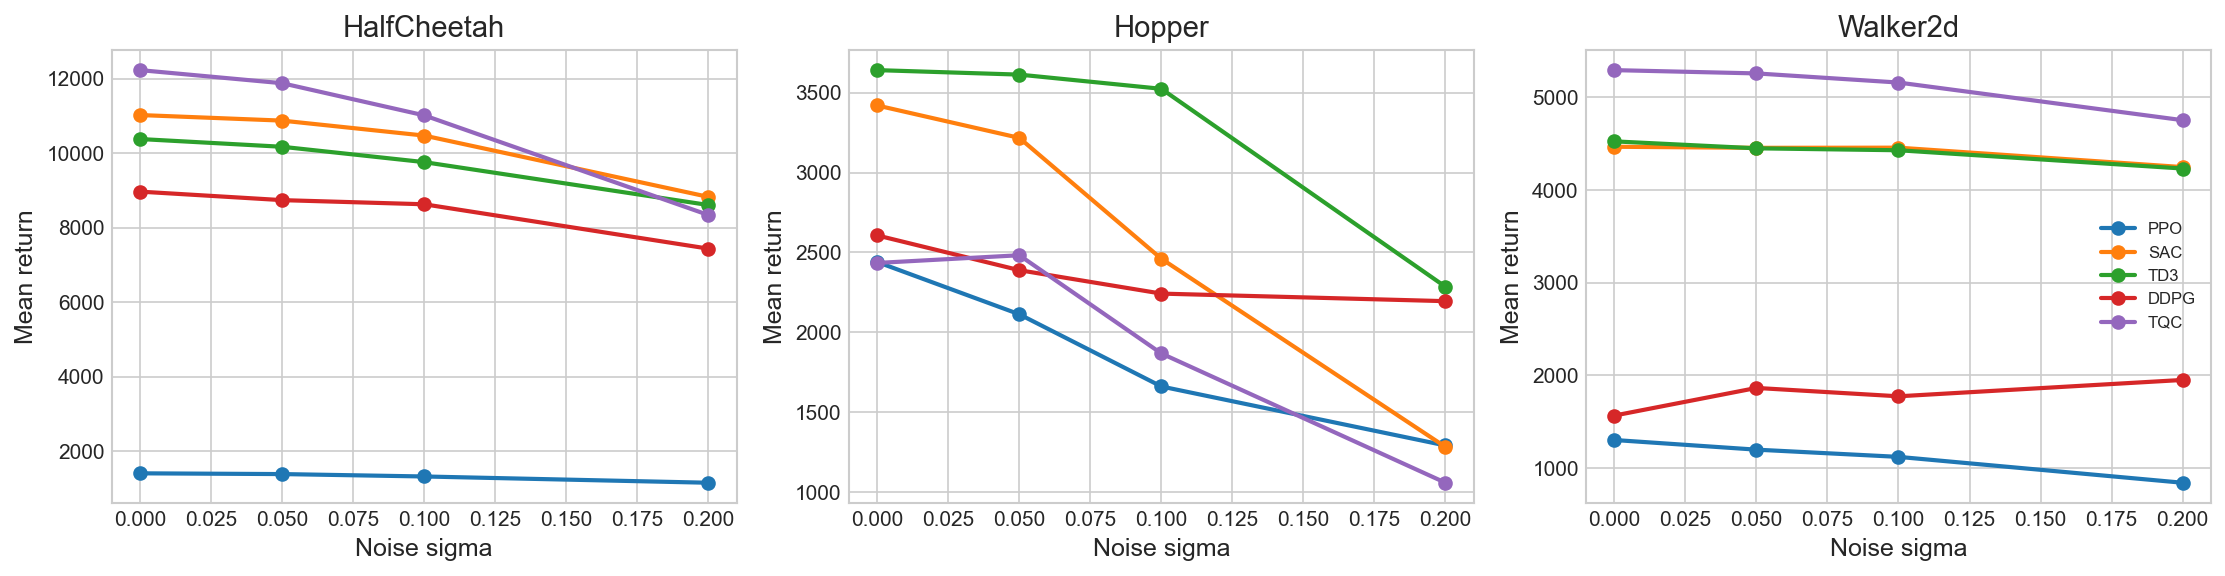

In [8]:
if not robust.empty:
    ret_col = "return" if "return" in robust.columns else "mean_return"
    noise_summary = (robust.groupby(["track", "env_id", "algorithm", "noise_sigma"])[ret_col]
                     .mean().reset_index(name="mean_return"))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, env_id in zip(axes, pu.ENV_IDS):
        data = noise_summary[(noise_summary["track"] == "tuned_1m") & (noise_summary["env_id"] == env_id)]
        for algo in pu.ALGORITHMS:
            part = data[data["algorithm"] == algo]
            if not part.empty:
                ax.plot(part["noise_sigma"], part["mean_return"], marker="o", label=algo)
        ax.set_title(env_id.replace("-v5", ""))
        ax.set_xlabel("Noise sigma")
        ax.set_ylabel("Mean return")
    axes[-1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()


## Walker2d fall rate by budget

Walker2d is the most stability-sensitive task, so we also inspect fall rate at
different training budgets. This helps show whether longer training reduces
early termination.

,env_id,algorithm,seed,total_timesteps,fall_rate,mean_ep_length
0,Walker2d-v5,PPO,2,100000,1.00,135.95
1,Walker2d-v5,PPO,2,500000,1.00,350.95
2,Walker2d-v5,PPO,2,1000000,0.00,1000.00
3,Walker2d-v5,PPO,1,100000,1.00,135.55
4,Walker2d-v5,PPO,1,500000,1.00,219.35
5,Walker2d-v5,PPO,1,1000000,0.95,451.90
6,Walker2d-v5,PPO,0,100000,1.00,142.65
7,Walker2d-v5,PPO,0,500000,0.95,427.50
8,Walker2d-v5,PPO,0,1000000,1.00,376.25
9,Walker2d-v5,TQC,2,100000,0.45,789.80


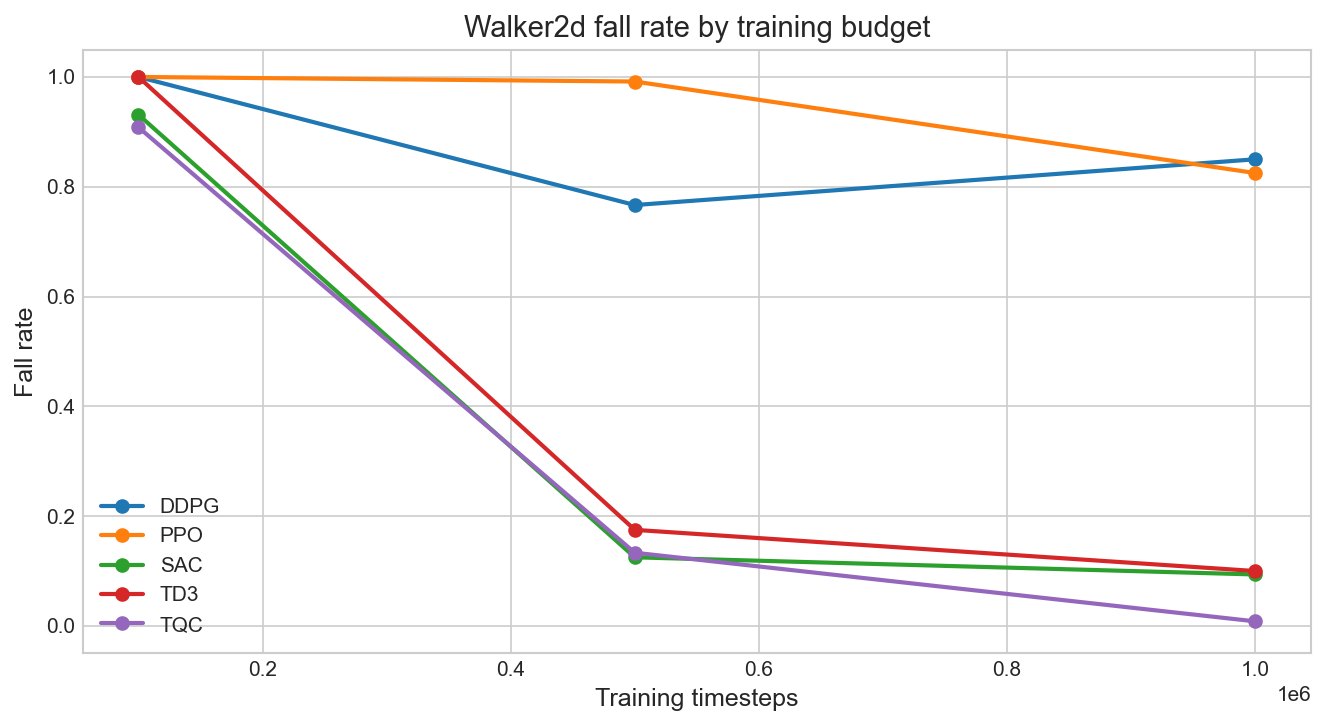

In [9]:
budget_path = pu.RESULTS_PROCESSED / "walker_fall_rate_by_budget.csv"
if budget_path.exists():
    budget = pd.read_csv(budget_path)
    display(budget.head(20))
    if "fall_rate" in budget.columns:
        fig, ax = plt.subplots(figsize=(9, 5))
        for algo in sorted(budget["algorithm"].dropna().unique()):
            part = budget[budget["algorithm"] == algo].groupby("total_timesteps")["fall_rate"].mean()
            ax.plot(part.index, part.values, marker="o", label=algo)
        ax.set_title("Walker2d fall rate by training budget")
        ax.set_xlabel("Training timesteps")
        ax.set_ylabel("Fall rate")
        ax.set_ylim(-0.05, 1.05)
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print("No checkpoint-budget table found.")


## Deterministic vs stochastic table

For stochastic-policy algorithms, this table compares deterministic evaluation
with stochastic evaluation. It helps separate policy quality from action-sampling
variance at test time.

In [10]:
dvs_path = pu.RESULTS_FINAL / "table_deterministic_vs_stochastic_eval.csv"
if dvs_path.exists():
    display(pd.read_csv(dvs_path))
else:
    print("The deterministic-vs-stochastic table has not been generated yet.")


,run_id,track,env_id,algorithm,setting_name,seed,return_deterministic,ep_length_deterministic,fall_rate_deterministic,return_stochastic,ep_length_stochastic,fall_rate_stochastic,delta_stochastic_minus_deterministic
0,Walker2d-v5__PPO__default_1m__sb3default__seed...,default_1m,Walker2d-v5,PPO,sb3default,2,3763.788330,1000.00,0.00,2579.000488,694.95,0.50,-1184.787842
1,Walker2d-v5__PPO__default_1m__sb3default__seed...,default_1m,Walker2d-v5,PPO,sb3default,1,1326.966064,451.90,0.95,1078.696777,342.00,1.00,-248.269287
2,Walker2d-v5__PPO__default_1m__sb3default__seed...,default_1m,Walker2d-v5,PPO,sb3default,0,1267.726318,376.25,1.00,1294.948486,391.60,1.00,27.222168
3,Hopper-v5__PPO__default_1m__sb3default__seed2_...,default_1m,Hopper-v5,PPO,sb3default,2,2182.206543,583.30,0.90,1598.353271,438.75,0.90,-583.853271
4,Hopper-v5__PPO__tuned_1m__vecnorm_large__seed1...,tuned_1m,Hopper-v5,PPO,vecnorm_large,1,2599.788574,774.40,0.55,2673.958984,801.55,0.55,74.170410
5,Hopper-v5__PPO__tuned_1m__vecnorm_large__seed0...,tuned_1m,Hopper-v5,PPO,vecnorm_large,0,1546.969238,438.10,1.00,1754.312744,498.45,1.00,207.343506
6,HalfCheetah-v5__PPO__tuned_1m__vecnorm_large__...,tuned_1m,HalfCheetah-v5,PPO,vecnorm_large,2,1625.378540,1000.00,0.00,1565.639404,1000.00,0.00,-59.739136
7,HalfCheetah-v5__PPO__tuned_1m__vecnorm_large__...,tuned_1m,HalfCheetah-v5,PPO,vecnorm_large,1,1020.285767,1000.00,0.00,981.211121,1000.00,0.00,-39.074646
8,HalfCheetah-v5__PPO__tuned_1m__vecnorm_large__...,tuned_1m,HalfCheetah-v5,PPO,vecnorm_large,0,1455.474365,1000.00,0.00,1383.909668,1000.00,0.00,-71.564697
9,Walker2d-v5__TQC__default_1m__sb3default__seed...,default_1m,Walker2d-v5,TQC,sb3default,2,4786.467773,1000.00,0.00,4604.104492,972.75,0.05,-182.363281
